<a href="https://colab.research.google.com/github/fahril168/machine-learning/blob/main/Analisis_Perbandingan_Model_Machine_Learning_untuk_Prediksi_Harga_Emas_Menggunakan_Linear_Regression_Random_Forest_dan_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [3]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# **Data Understanding**

In [13]:
import pandas as pd

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv('Gold Price (2013-2023).csv')

print("=== DATASET (5 BARIS PERTAMA) ===")
print(df.head())


# =========================
# 2. INFORMASI DATASET
# =========================
print("\n=== INFORMASI DATASET ===")
print(df.info())


# =========================
# 3. DESKRIPSI FITUR
# =========================
print("\n=== NAMA FITUR / KOLOM ===")
print(df.columns)


# =========================
# 4. STATISTIK DESKRIPTIF
# =========================
print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe(include='all'))

=== DATASET (5 BARIS PERTAMA) ===
         Date     Price      Open      High       Low     Vol. Change %
0  12/30/2022  1,826.20  1,821.80  1,832.40  1,819.80  107.50K    0.01%
1  12/29/2022  1,826.00  1,812.30  1,827.30  1,811.20  105.99K    0.56%
2  12/28/2022  1,815.80  1,822.40  1,822.80  1,804.20  118.08K   -0.40%
3  12/27/2022  1,823.10  1,808.20  1,841.90  1,808.00  159.62K    0.74%
4  12/26/2022  1,809.70  1,805.80  1,811.95  1,805.55      NaN    0.30%

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2583 non-null   object
 1   Price     2583 non-null   object
 2   Open      2583 non-null   object
 3   High      2583 non-null   object
 4   Low       2583 non-null   object
 5   Vol.      2578 non-null   object
 6   Change %  2583 non-null   object
dtypes: object(7)
memory usage: 141.4+ KB
None

=== NAMA FI

# **Data Preprocessing**

In [5]:
def convert_volume(val):
    try:
        if isinstance(val, str):
            val = val.strip()

            if val == '-' or val == '':
                return 0

            if val.endswith('K'):
                return float(val[:-1]) * 1_000
            elif val.endswith('M'):
                return float(val[:-1]) * 1_000_000
            elif val.endswith('B'):
                return float(val[:-1]) * 1_000_000_000
            else:
                return float(val)
        return val
    except:
        return 0


# =========================
# CLEANING
# =========================
for col in ['Price', 'Open', 'High', 'Low']:
    df[col] = df[col].str.replace(',', '').astype(float)

df['Change %'] = df['Change %'].str.replace('%', '').astype(float)
df['Vol.'] = df['Vol.'].apply(convert_volume)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# =========================
# MISSING VALUE
# =========================
print(df.isnull().sum())
df = df.dropna()

# =========================
# OUTLIER (IQR)
# =========================
Q1 = df[['Price', 'Open', 'High', 'Low']].quantile(0.25)
Q3 = df[['Price', 'Open', 'High', 'Low']].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[['Price', 'Open', 'High', 'Low']] < (Q1 - 1.5 * IQR)) |
          (df[['Price', 'Open', 'High', 'Low']] > (Q3 + 1.5 * IQR))).any(axis=1)]

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        5
Change %    0
dtype: int64


**Feature Engineering**

In [6]:
df['lag_1'] = df['Price'].shift(1)
df['lag_2'] = df['Price'].shift(2)

df = df.dropna()

**Feature & Target**

In [7]:
X = df[['Open', 'High', 'Low', 'Vol.', 'Change %',
        'lag_1', 'lag_2']]

y = df['Price']

# **Exploratory Data Analysis (EDA)**

<Figure size 1000x800 with 0 Axes>

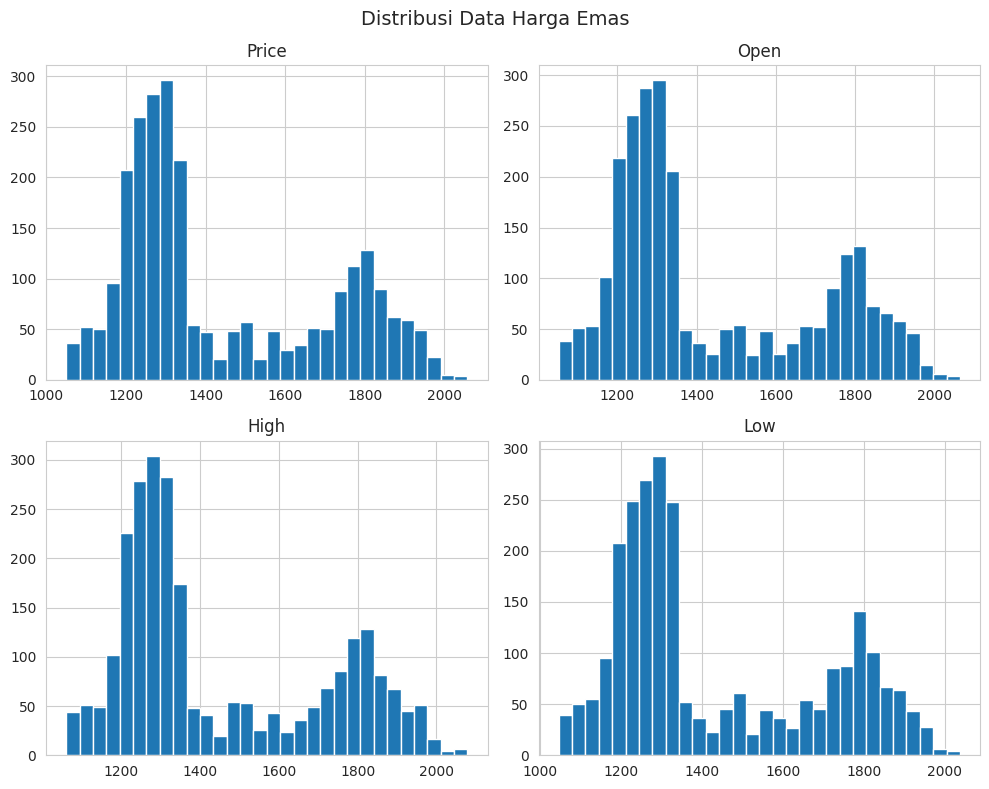

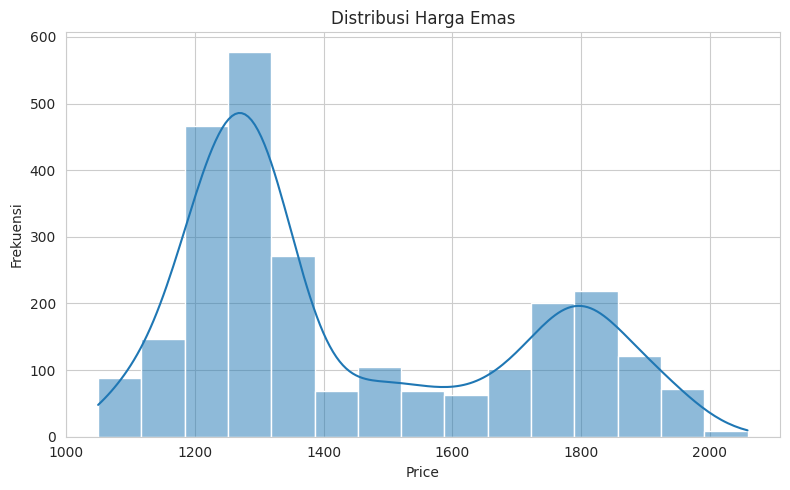

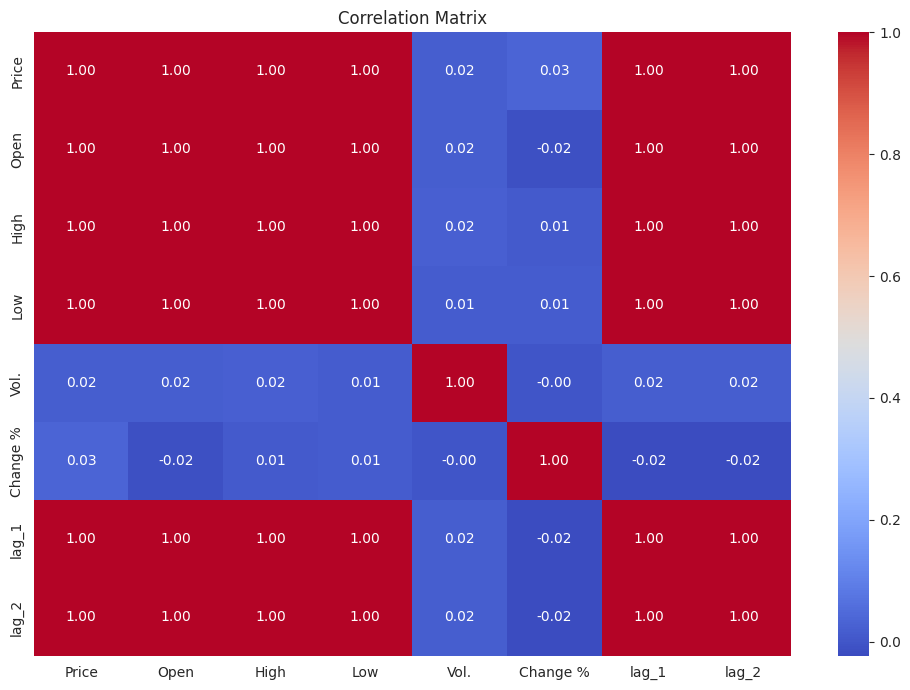

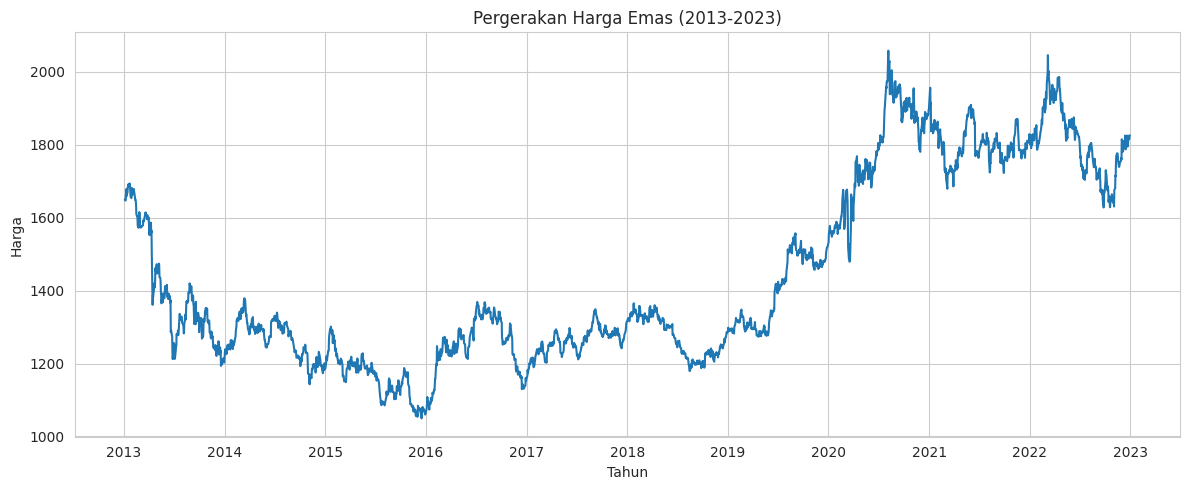

In [8]:
import seaborn as sns

# =========================
# SET STYLE (BIAR BAGUS)
# =========================
sns.set_style('whitegrid')

# =========================
# 1. DISTRIBUSI DATA
# =========================
plt.figure(figsize=(10,8))
df[['Price', 'Open', 'High', 'Low']].hist(bins=30, figsize=(10,8))
plt.suptitle('Distribusi Data Harga Emas', fontsize=14)
plt.tight_layout()
plt.show()

# =========================
# 2. DISTRIBUSI KHUSUS PRICE
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribusi Harga Emas')
plt.xlabel('Price')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# =========================
# 3. KORELASI (HANYA NUMERIK)
# =========================
num_cols = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,7))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# =========================
# 4. TIME SERIES
# =========================
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Price'])
plt.title('Pergerakan Harga Emas (2013-2023)')
plt.xlabel('Tahun')
plt.ylabel('Harga')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Function Evaluasi**

In [9]:
def evaluate_split(split_ratio):

    # ================================
    # Data Splitting (Time Series)
    # ================================
    train_size = int(len(df) * split_ratio)

    X_train = X[:train_size]
    X_test = X[train_size:]
    y_train = y[:train_size]
    y_test = y[train_size:]

    print("\n" + "="*50)
    print(f"         SPLIT {round(split_ratio*100)}:{round((1-split_ratio)*100)}")
    print("="*50)

    # ================================
    # NORMALISASI (ANTI DATA LEAKAGE)
    # ================================
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()

    X_train = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X.columns,
        index=X_train.index
    )

    X_test = pd.DataFrame(
        scaler.transform(X_test),
        columns=X.columns,
        index=X_test.index
    )

    # ================================
    # Cross Validation (Time Series)
    # ================================
    from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV

    tscv = TimeSeriesSplit(n_splits=5)

    # ================================
    # Linear Regression
    # ================================
    from sklearn.linear_model import LinearRegression

    lr = LinearRegression()
    lr_param_grid = {
        'fit_intercept': [True, False],
        'positive': [True, False]
    }

    lr_grid = GridSearchCV(lr, lr_param_grid, cv=tscv, n_jobs=-1)
    lr_grid.fit(X_train, y_train)
    best_lr = lr_grid.best_estimator_

    # ================================
    # Random Forest
    # ================================
    from sklearn.ensemble import RandomForestRegressor

    rf = RandomForestRegressor(random_state=42)

    rf_param_grid = {
        'n_estimators': [100, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2, 4]
    }

    rf_grid = GridSearchCV(rf, rf_param_grid, cv=tscv, n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    best_rf = rf_grid.best_estimator_

    # ================================
    # XGBoost
    # ================================
    from xgboost import XGBRegressor

    xgb = XGBRegressor(random_state=42)

    xgb_param_dist = {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1],
        'colsample_bytree': [0.8, 1]
    }

    xgb_random = RandomizedSearchCV(
        xgb,
        xgb_param_dist,
        n_iter=10,
        cv=tscv,
        random_state=42,
        n_jobs=-1
    )

    xgb_random.fit(X_train, y_train)
    best_xgb = xgb_random.best_estimator_

    # ================================
    # TAMPILKAN HASIL TUNING
    # ================================
    print("\n🎯 BEST HYPERPARAMETERS")
    print("-"*50)
    print("Best LR Params  :", lr_grid.best_params_)
    print("Best RF Params  :", rf_grid.best_params_)
    print("Best XGB Params :", xgb_random.best_params_)

    # ================================
    # Model
    # ================================
    models = {
        "Linear Regression": best_lr,
        "Random Forest": best_rf,
        "XGBoost": best_xgb
    }

    predictions = {}

    print("\n📊 HASIL EVALUASI MODEL")
    print("-"*50)

    # ================================
    # Training & Evaluasi
    # ================================
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.metrics import mean_absolute_percentage_error
    import numpy as np

    for name, model in models.items():

        if name == "XGBoost":
            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False
            )
        else:
            model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        predictions[name] = y_pred

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        train_r2 = model.score(X_train, y_train)
        test_r2 = model.score(X_test, y_test)
        gap = train_r2 - test_r2

        print(f"\n🔹 {name}")
        print(f"{'-'*30}")
        print(f"MAE              : {mae:.4f}")
        print(f"MSE              : {mse:.4f}")
        print(f"RMSE             : {rmse:.4f}")
        print(f"MAPE             : {mape*100:.2f}%")
        print(f"R² Score         : {r2:.4f}")
        print(f"Train R²         : {train_r2:.4f}")
        print(f"Test R²          : {test_r2:.4f}")
        print(f"Overfitting Gap  : {gap:.4f}")

    # ================================
    # Visualisasi
    # ================================
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, (name, y_pred) in zip(axes, predictions.items()):
        ax.plot(y_test.reset_index(drop=True), label='Actual')
        ax.plot(pd.Series(y_pred), label='Predicted')
        ax.set_title(name)
        ax.legend()

    fig.suptitle(f'Actual vs Predicted - Split {round(split_ratio*100)}:{round((1-split_ratio)*100)}')
    plt.tight_layout()
    plt.show()

# **Jalankan Semua Split**


         SPLIT 80:20

🎯 BEST HYPERPARAMETERS
--------------------------------------------------
Best LR Params  : {'fit_intercept': True, 'positive': False}
Best RF Params  : {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best XGB Params : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1}

📊 HASIL EVALUASI MODEL
--------------------------------------------------

🔹 Linear Regression
------------------------------
MAE              : 2.6368
MSE              : 13.2941
RMSE             : 3.6461
MAPE             : 0.15%
R² Score         : 0.9975
Train R²         : 0.9999
Test R²          : 0.9975
Overfitting Gap  : 0.0024

🔹 Random Forest
------------------------------
MAE              : 6.2451
MSE              : 66.3762
RMSE             : 8.1472
MAPE             : 0.35%
R² Score         : 0.9877
Train R²         : 0.9998
Test R²          : 0.9877
Overfitting Gap  : 0.0121

🔹 XGBoost
-----------------

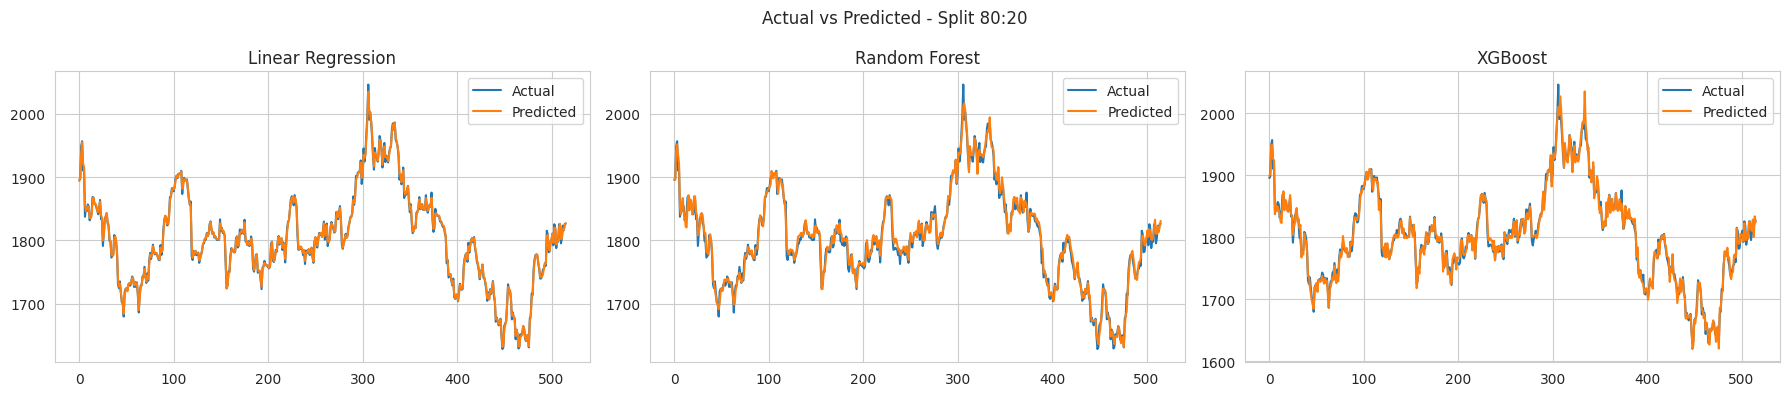


         SPLIT 85:15

🎯 BEST HYPERPARAMETERS
--------------------------------------------------
Best LR Params  : {'fit_intercept': True, 'positive': False}
Best RF Params  : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best XGB Params : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1}

📊 HASIL EVALUASI MODEL
--------------------------------------------------

🔹 Linear Regression
------------------------------
MAE              : 2.4261
MSE              : 10.7208
RMSE             : 3.2743
MAPE             : 0.13%
R² Score         : 0.9982
Train R²         : 0.9999
Test R²          : 0.9982
Overfitting Gap  : 0.0017

🔹 Random Forest
------------------------------
MAE              : 5.4946
MSE              : 52.0308
RMSE             : 7.2132
MAPE             : 0.30%
R² Score         : 0.9911
Train R²         : 0.9999
Test R²          : 0.9911
Overfitting Gap  : 0.0088

🔹 XGBoost
-----------------

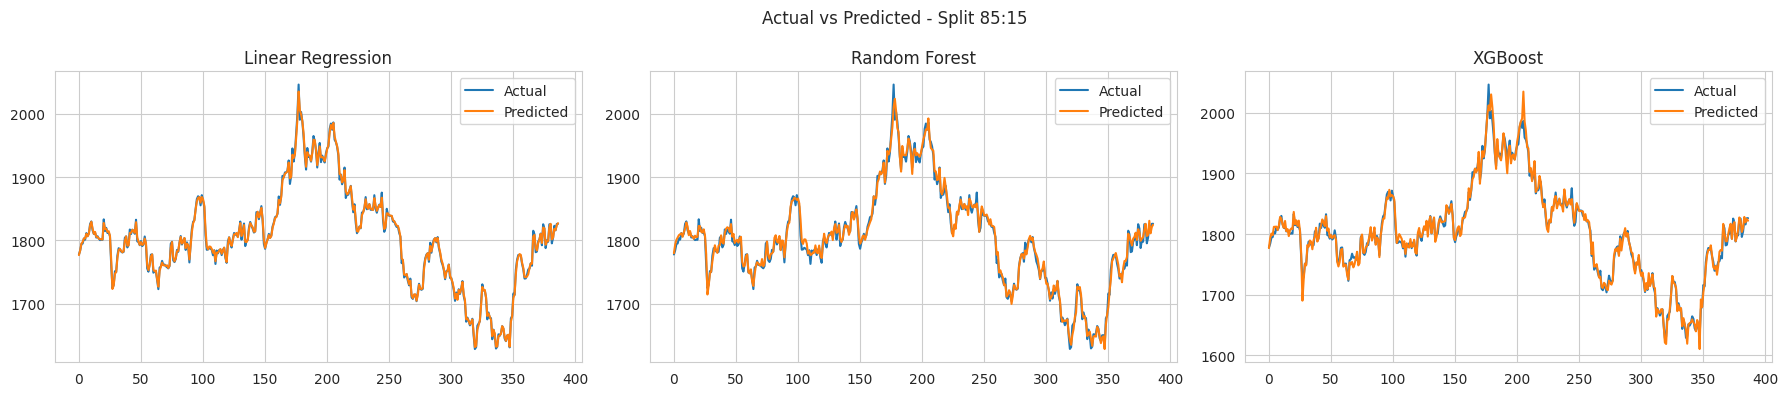


         SPLIT 90:10

🎯 BEST HYPERPARAMETERS
--------------------------------------------------
Best LR Params  : {'fit_intercept': True, 'positive': False}
Best RF Params  : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best XGB Params : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1}

📊 HASIL EVALUASI MODEL
--------------------------------------------------

🔹 Linear Regression
------------------------------
MAE              : 2.5359
MSE              : 11.6826
RMSE             : 3.4180
MAPE             : 0.14%
R² Score         : 0.9986
Train R²         : 0.9999
Test R²          : 0.9986
Overfitting Gap  : 0.0013

🔹 Random Forest
------------------------------
MAE              : 5.2081
MSE              : 49.6802
RMSE             : 7.0484
MAPE             : 0.29%
R² Score         : 0.9940
Train R²         : 0.9999
Test R²          : 0.9940
Overfitting Gap  : 0.0059

🔹 XGBoost
---------------

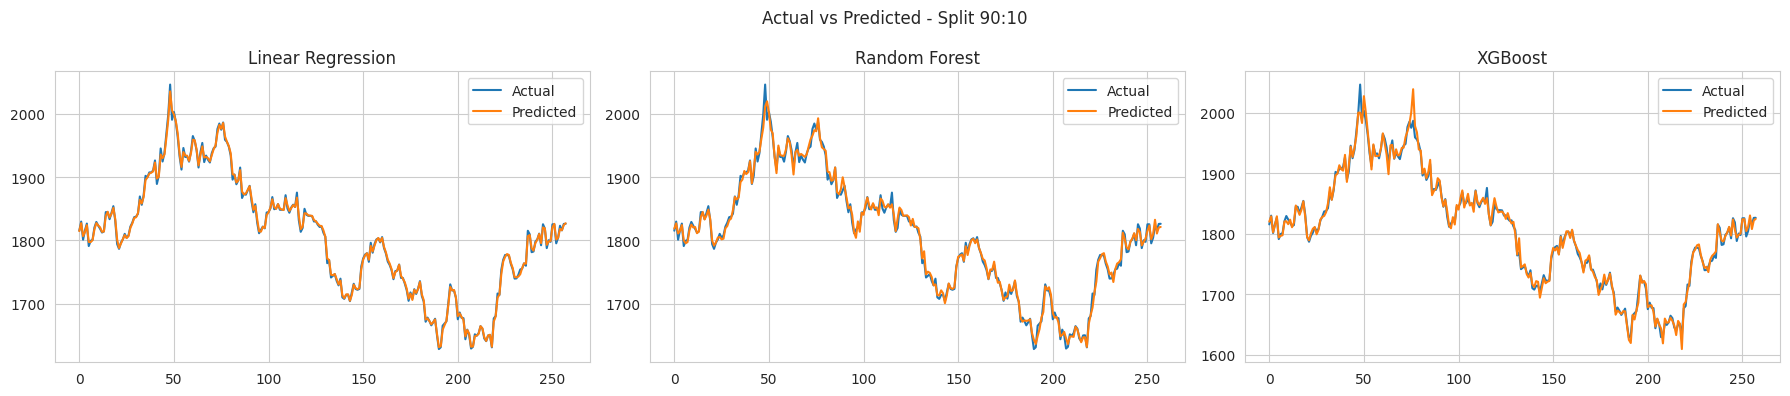

In [11]:
evaluate_split(0.8)   # 80:20
evaluate_split(0.85)  # 85:15
evaluate_split(0.9)   # 90:10

In [12]:
# contoh training final (pakai seluruh data)
lr = LinearRegression().fit(X, y)
rf = RandomForestRegressor().fit(X, y)
xgb = XGBRegressor().fit(X, y)

joblib.dump(lr, 'lr.pkl')
joblib.dump(rf, 'rf.pkl')
joblib.dump(xgb, 'xgb.pkl')

['xgb.pkl']